<a href="https://colab.research.google.com/github/RenukaSiriwardhana/Skin-Cancer-Detection--DermaVision/blob/main/notebooks/Implementation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/DermaVision/kaggle/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured...")

Kaggle API configured...


In [3]:
import os

DRIVE_ZIP_PATH = "/content/drive/MyDrive/DermaVision/dataset_cache/ham10000-split-and-augmented.zip"
EXTRACT_PATH = "/content/ham10000_dataset"

os.makedirs("/content/drive/MyDrive/DermaVision/dataset_cache", exist_ok=True)

if not os.path.exists(DRIVE_ZIP_PATH):
    print("Downloading dataset from Kaggle (one time only)...")
    !kaggle datasets download -d ahefatresearch/ham10000-split-and-augmented -p /content --force
    !cp /content/ham10000-split-and-augmented.zip "{DRIVE_ZIP_PATH}"
    print("Dataset zip saved to Drive ")
else:
    print("Dataset already exists in Drive (Skipping download)")

Dataset already exists in Drive (Skipping download)


In [4]:
import zipfile
import os

DRIVE_ZIP_PATH = "/content/drive/MyDrive/DermaVision/dataset_cache/ham10000-split-and-augmented.zip"
EXTRACT_PATH = "/content/ham10000_dataset"

# Extract dataset if not already extracted
if not os.path.exists(EXTRACT_PATH):
    print("Extracting dataset...")

    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("Extraction completed")
else:
    print("Dataset already extracted")

Extracting dataset...
Extraction completed


In [5]:
import os

print(os.listdir("/content/ham10000_dataset"))

['val_dir', 'test_dir', 'train_dir']


In [6]:
train_dir = "/content/ham10000_dataset/val_dir"
val_dir = "/content/ham10000_dataset/train_dir"
test_dir = "/content/ham10000_dataset/test_dir"

In [7]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'ham10000_dataset', 'sample_data']


In [8]:
import os
print(os.listdir("/content/ham10000_dataset"))

['val_dir', 'test_dir', 'train_dir']


In [9]:
import os

train_dir = "/content/ham10000_dataset/train_dir"
val_dir = "/content/ham10000_dataset/val_dir"
test_dir = "/content/ham10000_dataset/test_dir"

def count_images(directory):

    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))

    return class_counts


print("Training Data Distribution")
print(count_images(train_dir))

print("\nValidation Data Distribution")
print(count_images(val_dir))

print("\nTesting Data Distribution")
print(count_images(test_dir))

Training Data Distribution
{'bkl': 7944, 'bcc': 7965, 'df': 7377, 'mel': 7932, 'akiec': 7854, 'nv': 8004, 'vasc': 7706}

Validation Data Distribution
{'bkl': 66, 'bcc': 26, 'df': 6, 'mel': 34, 'akiec': 23, 'nv': 662, 'vasc': 10}

Testing Data Distribution
{'bkl': 66, 'bcc': 27, 'df': 6, 'mel': 35, 'akiec': 22, 'nv': 663, 'vasc': 9}


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dir = "/content/ham10000_dataset/train_dir"
val_dir = "/content/ham10000_dataset/val_dir"
test_dir = "/content/ham10000_dataset/test_dir"

In [11]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation & test preprocessing
test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Preprocessing completed successfully")

Found 54782 images belonging to 7 classes.
Found 827 images belonging to 7 classes.
Found 828 images belonging to 7 classes.
Preprocessing completed successfully


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization

In [14]:
model = Sequential()

# Block 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Classification Layer
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,759 (42.61 MB)

 Trainable params: 11,170,311 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [17]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 785s 453ms/step - accuracy: 0.3315 - loss: 1.9380 - val_accuracy: 0.6651 - val_loss: 0.8913
Epoch 2/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 747s 436ms/step - accuracy: 0.3934 - loss: 1.5412 - val_accuracy: 0.5260 - val_loss: 1.7083
Epoch 3/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 743s 434ms/step - accuracy: 0.4226 - loss: 1.4435 - val_accuracy: 0.7110 - val_loss: 0.7997
Epoch 4/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 728s 425ms/step - accuracy: 0.4532 - loss: 1.3619 - val_accuracy: 0.4933 - val_loss: 1.5178
Epoch 5/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 743s 434ms/step - accuracy: 0.4696 - loss: 1.3152 - val_accuracy: 0.8114 - val_loss: 0.9554
Epoch 6/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 726s 424ms/step - accuracy: 0.4860 - loss: 1.2558 - val_accuracy: 0.5296 - val_loss: 1.2870
Epoch 7/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 731s 427ms/step - accuracy: 0.4983 - loss: 1.2324 - val_accuracy: 0.7062 - val_loss: 0.8029
Epoch 8/30
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 737s 430ms/step - ac

In [18]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 323ms/step - accuracy: 0.6151 - loss: 1.0123
Test Accuracy: 0.6823671460151672
Test Loss: 0.8099019527435303


In [20]:
# Predictions
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step
              precision    recall  f1-score   support

       akiec       0.29      0.27      0.28        22
         bcc       0.31      0.37      0.34        27
         bkl       0.22      0.62      0.33        66
          df       0.00      0.00      0.00         6
         mel       0.17      0.31      0.22        35
          nv       0.96      0.74      0.84       663
        vasc       1.00      0.44      0.62         9

    accuracy                           0.68       828
   macro avg       0.42      0.40      0.37       828
weighted avg       0.82      0.68      0.73       828



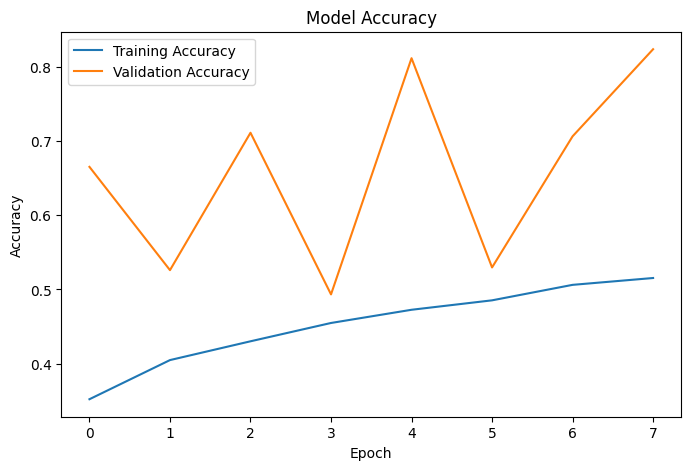

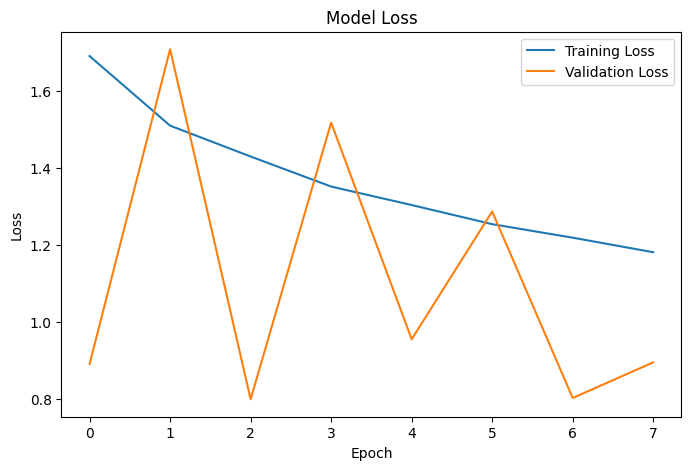

In [21]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Loss graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

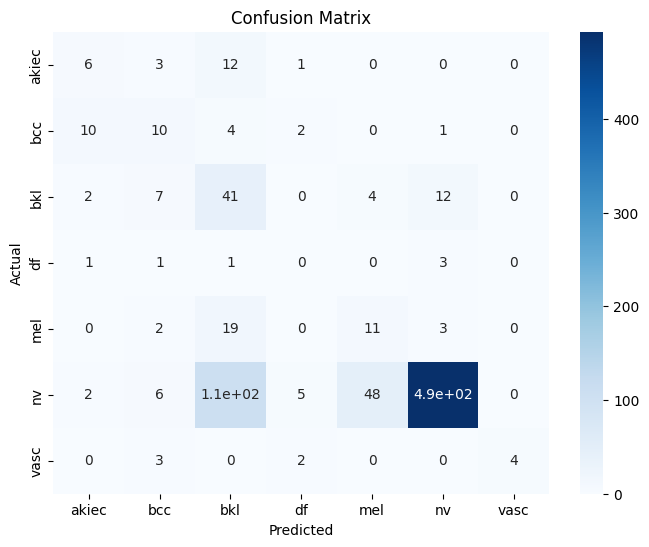

In [22]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Save model
model.save("/content/drive/MyDrive/DermaVision/model_v2.h5")

print("Model saved successfully!")

Model saved successfully!
